In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 200

data = {
    "order_id": range(1001, 1001 + n),
    "city": np.random.choice(["Mumbai", "Delhi", "Bangalore", "Chennai"], size=n),
    "category": np.random.choice(["Electronics", "Clothing", "Groceries", "Furniture"], size=n),
    "order_value": np.random.randint(200, 5000, size=n).astype(float),
    "delivery_days": np.random.randint(1, 15, size=n).astype(float),
    "rating": np.random.choice([1, 2, 3, 4, 5, None], size=n)
}

missing_indices_order = np.random.choice(n, size=15, replace=False)
missing_indices_delivery = np.random.choice(n, size=10, replace=False)
data["order_value"][missing_indices_order] = np.nan
data["delivery_days"][missing_indices_delivery] = np.nan

data["order_value"][5] = 95000
data["order_value"][88] = 87000

df = pd.DataFrame(data)
print(df.shape)
df.head()


(200, 6)


,order_id,city,category,order_value,delivery_days,rating
0,1001,Bangalore,Groceries,4191.0,11.0,4
1,1002,Chennai,Furniture,4923.0,12.0,1
2,1003,Mumbai,Groceries,4882.0,13.0,2
3,1004,Bangalore,Electronics,1848.0,13.0,1
4,1005,Bangalore,Furniture,1645.0,12.0,1


In [2]:
#Task 1 — Inspect & Handle Missing Values

# 1. Print shape of DataFrame
print("Shape of DataFrame:", df.shape)

# 2. Display data types
print("\nData Types:\n", df.dtypes)

# 3. Count missing values in each column
missing_count = df.isnull().sum()
print("\nMissing Values Count:\n", missing_count)

# 4. Percentage of missing values
missing_percent = (missing_count / len(df)) * 100
missing_percent = missing_percent.round(2)

print("\nMissing Values Percentage:\n", missing_percent)

Shape of DataFrame: (200, 6)

Data Types:
 order_id           int64
city              object
category          object
order_value      float64
delivery_days    float64
rating            object
dtype: object

Missing Values Count:
 order_id          0
city              0
category          0
order_value      14
delivery_days    10
rating           32
dtype: int64

Missing Values Percentage:
 order_id          0.0
city              0.0
category          0.0
order_value       7.0
delivery_days     5.0
rating           16.0
dtype: float64


In [3]:
#Task 2 — Summarize & Visualize

# Summary of numerical columns
summary = df.describe()
print(summary)

          order_id   order_value  delivery_days
count   200.000000    186.000000     190.000000
mean   1100.500000   3707.134409       7.810526
std      57.879185   9238.438378       4.075465
min    1001.000000    204.000000       1.000000
25%    1050.750000   1512.000000       4.000000
50%    1100.500000   2934.000000       8.000000
75%    1150.250000   3987.500000      12.000000
max    1200.000000  95000.000000      14.000000


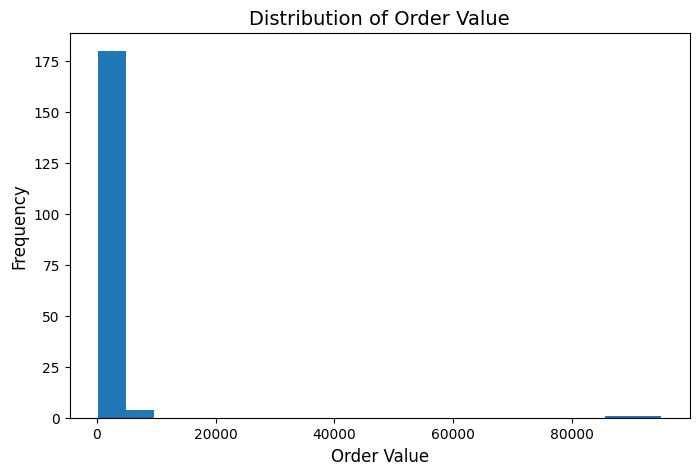

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['order_value'].dropna(), bins=20)

plt.title('Distribution of Order Value', fontsize=14)
plt.xlabel('Order Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.show()

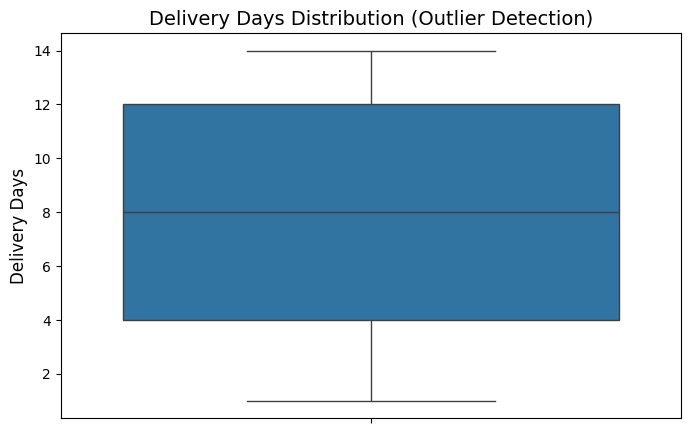

In [5]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(y=df['delivery_days'])

plt.title('Delivery Days Distribution (Outlier Detection)', fontsize=14)
plt.ylabel('Delivery Days', fontsize=12)

plt.show()

In [6]:
#Task 3 — Correlation Analysis

# Correlation matrix
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

               order_id  order_value  delivery_days
order_id       1.000000    -0.095503       0.004858
order_value   -0.095503     1.000000       0.141660
delivery_days  0.004858     0.141660       1.000000


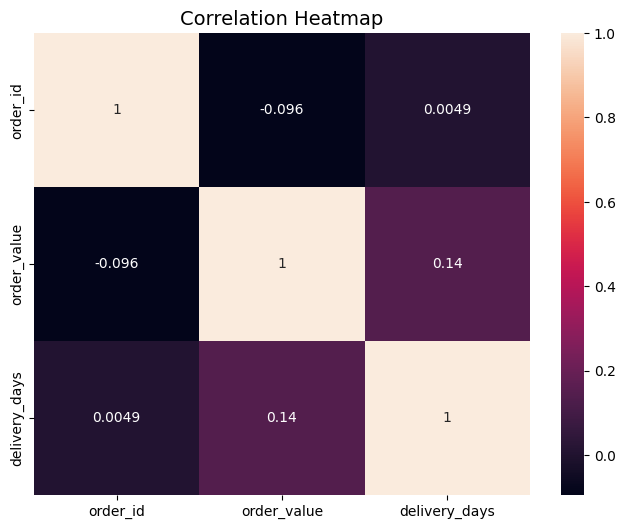

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True)

plt.title('Correlation Heatmap', fontsize=14)
plt.show()